# Blocks Signal vs Official Takedown 

Questo notebook usa **solo** i dataset `v3` in `datasets/balduf_anon_march_2026/` per valutare in modo descrittivo se i blocchi ricevuti dagli account su Bluesky contengano un segnale informativo rispetto al successivo takedown ufficiale.

Obiettivi:
- confrontare positivi e negativi a parita' approssimata di esposizione;
- distinguere presenza del segnale, intensita' del segnale e timing del segnale;
- dedicare una sezione specifica agli account con `0 post` e `0 incoming follows`, dato che li vogliamo capire meglio per analisi successive.


In [2]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.patches import Patch
from matplotlib.ticker import PercentFormatter

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

COLORS = {
    "negative": "#4C78A8",
    "positive": "#E45756",
}

MIN_POS_BUCKET = 20
MIN_NEG_BUCKET = 200

ROOT = Path.cwd()
if not (ROOT / "datasets" / "balduf_anon_march_2026").exists():
    for candidate in [ROOT, *ROOT.parents]:
        if (candidate / "datasets" / "balduf_anon_march_2026").exists():
            ROOT = candidate
            break
    else:
        raise FileNotFoundError("Could not locate datasets/balduf_anon_march_2026 from the current working directory.")

DATA_DIR = ROOT / "datasets" / "balduf_anon_march_2026"
POS_FILE = DATA_DIR / "positive_blocks_analysis_10d_mar2026_v3_anon.parquet"
NEG_FILE = DATA_DIR / "negative_blocks_analysis_10d_mar2026_v3_anon.parquet"

for path in [POS_FILE, NEG_FILE]:
    if not path.exists():
        raise FileNotFoundError(path)

con = duckdb.connect()
con.execute(
    f"""
    CREATE OR REPLACE VIEW blocks AS
    SELECT 'positive' AS sample, * FROM read_parquet('{POS_FILE.as_posix()}')
    UNION ALL
    SELECT 'negative' AS sample, * FROM read_parquet('{NEG_FILE.as_posix()}')
    """
)

def q(sql: str) -> pd.DataFrame:
    return con.execute(sql).df()

schema_df = q("DESCRIBE blocks")

print("Positive file:", POS_FILE)
print("Negative file:", NEG_FILE)
display(schema_df)


Positive file: c:\Users\Nico\Documents\Bluesky\Bluesky-moderation-analysis\datasets\balduf_anon_march_2026\positive_blocks_analysis_10d_mar2026_v3_anon.parquet
Negative file: c:\Users\Nico\Documents\Bluesky\Bluesky-moderation-analysis\datasets\balduf_anon_march_2026\negative_blocks_analysis_10d_mar2026_v3_anon.parquet


,column_name,column_type,null,key,default,extra
0,sample,VARCHAR,YES,None,None,None
1,did_anon,VARCHAR,YES,None,None,None
2,target,INTEGER,YES,None,None,None
3,event_time,TIMESTAMP,YES,None,None,None
4,event_day,DATE,YES,None,None,None
5,window_start,TIMESTAMP,YES,None,None,None
6,window_end,TIMESTAMP,YES,None,None,None
7,n_posts_10d,BIGINT,YES,None,None,None
8,n_blocks_received_10d,BIGINT,YES,None,None,None
9,n_unique_blockers_10d,BIGINT,YES,None,None,None


## 1. Quadro generale

Partiamo da una vista molto semplice del dataset:
- quante osservazioni positive e quante negative abbiamo;
- quanti account unici sono coinvolti;
- qual e' la quota di osservazioni con almeno un blocco nei 10 giorni pre-evento.


,sample,n_obs,n_unique_accounts,share_has_block_10d
0,negative,4031665,366515,0.1809
1,positive,47821,47821,0.2782


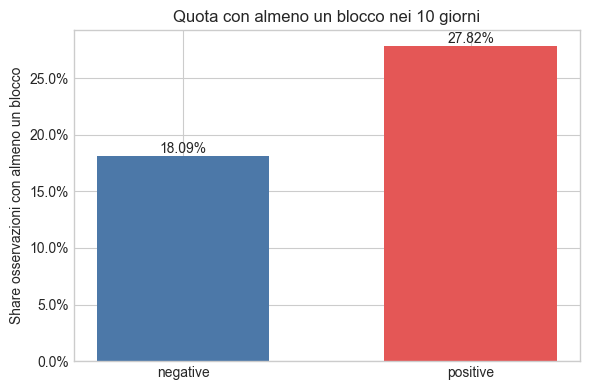

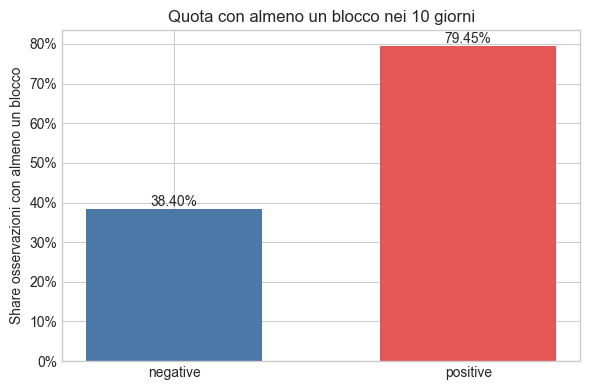

In [3]:
headline = q(
    """
    SELECT
        sample,
        COUNT(*) AS n_obs,
        COUNT(DISTINCT did_anon) AS n_unique_accounts,
        AVG(has_block_10d) AS share_has_block_10d
    FROM blocks
    GROUP BY sample
    ORDER BY sample
    """
)
display(headline)

headline_no00 = q(
    """
    SELECT
        sample,
        COUNT(*) AS n_obs,
        COUNT(DISTINCT did_anon) AS n_unique_accounts,
        AVG(has_block_10d) AS share_has_block_10d
    FROM blocks
    WHERE post_bucket_index != 0 AND follow_10d_bucket_index != 0
    GROUP BY sample
    ORDER BY sample
    """
)

bars = headline.set_index("sample")["share_has_block_10d"].reindex(["negative", "positive"])

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(
    bars.index,
    bars.values,
    color=[COLORS["negative"], COLORS["positive"]],
    width=0.6,
)
ax.set_title("Quota con almeno un blocco nei 10 giorni")
ax.set_ylabel("Share osservazioni con almeno un blocco")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

for idx, value in enumerate(bars.values):
    ax.text(idx, value, f"{value:.2%}", ha="center", va="bottom")

fig.tight_layout()
plt.show()

bars_no00 = headline_no00.set_index("sample")["share_has_block_10d"].reindex(["negative", "positive"])

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(
    bars_no00.index,
    bars_no00.values,
    color=[COLORS["negative"], COLORS["positive"]],
    width=0.6,
)
ax.set_title("Quota con almeno un blocco nei 10 giorni")
ax.set_ylabel("Share osservazioni con almeno un blocco")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

for idx, value in enumerate(bars_no00.values):
    ax.text(idx, value, f"{value:.2%}", ha="center", va="bottom")

fig.tight_layout()
plt.show()


## 2. Istogrammi per `post_bucket_index`

Facciamo due grafici a barre affiancate:
- a sinistra: numero medio di blocchi ricevuti nei 10 giorni;
- a destra: quota di osservazioni con almeno un blocco.

Manteniamo solo i bucket con supporto minimo in entrambi i gruppi, cosi' la lettura resta stabile anche nelle code.


,post_bucket_index,n_pos,n_neg,pos_mean_blocks_10d,neg_mean_blocks_10d,pos_share_has_block_10d,neg_share_has_block_10d
0,0,34716,1765748,0.7287,0.0875,0.1201,0.0350
1,1,4259,365923,10.8206,0.2431,0.6105,0.0982
2,2,2379,239081,5.0361,0.3604,0.6641,0.1309
3,3,2953,403804,7.0586,0.5926,0.6901,0.1787
4,4,1641,330656,7.8178,1.0014,0.7861,0.2436
5,5,1074,380877,9.7598,1.5463,0.8547,0.3362
6,6,313,217189,15.6454,2.6222,0.8690,0.4539
7,7,174,155182,23.6724,3.7878,0.9080,0.5762
8,8,128,117309,39.0469,7.2700,0.8672,0.7145
9,9,76,38442,47.1579,13.4290,0.8684,0.8311


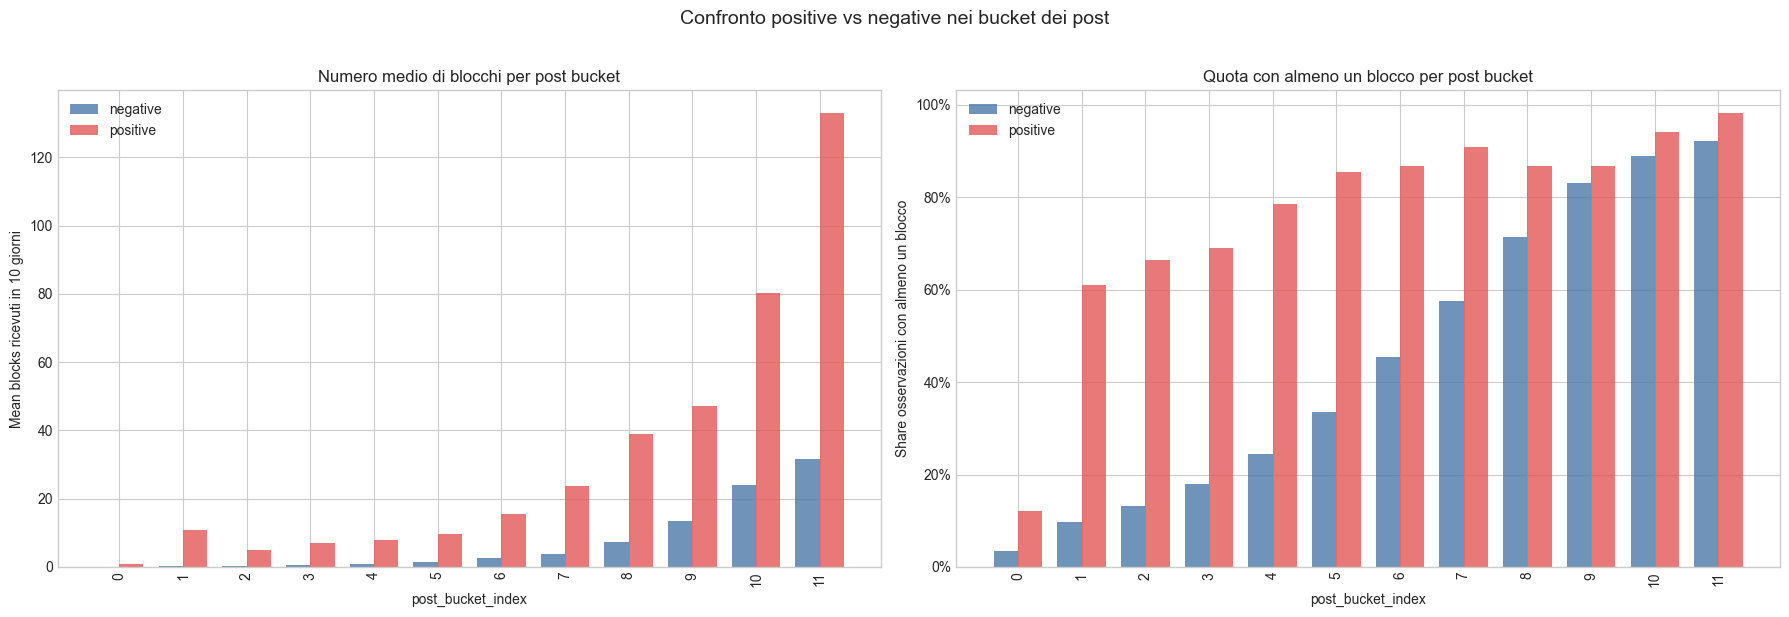

In [4]:
post_bucket_plot = q(
    f"""
    WITH bucket_stats AS (
        SELECT
            sample,
            post_bucket_index,
            COUNT(*) AS n_obs,
            AVG(n_blocks_received_10d) AS mean_blocks_10d,
            AVG(has_block_10d) AS share_has_block_10d
        FROM blocks
        GROUP BY sample, post_bucket_index
    ),
    wide AS (
        SELECT
            post_bucket_index,
            MAX(CASE WHEN sample = 'positive' THEN n_obs END) AS n_pos,
            MAX(CASE WHEN sample = 'negative' THEN n_obs END) AS n_neg,
            MAX(CASE WHEN sample = 'positive' THEN mean_blocks_10d END) AS pos_mean_blocks_10d,
            MAX(CASE WHEN sample = 'negative' THEN mean_blocks_10d END) AS neg_mean_blocks_10d,
            MAX(CASE WHEN sample = 'positive' THEN share_has_block_10d END) AS pos_share_has_block_10d,
            MAX(CASE WHEN sample = 'negative' THEN share_has_block_10d END) AS neg_share_has_block_10d
        FROM bucket_stats
        GROUP BY post_bucket_index
    )
    SELECT *
    FROM wide
    WHERE COALESCE(n_pos, 0) >= {MIN_POS_BUCKET}
      AND COALESCE(n_neg, 0) >= {MIN_NEG_BUCKET}
    ORDER BY post_bucket_index
    """
)

display(post_bucket_plot)

x = np.arange(len(post_bucket_plot))
width = 0.38
labels = post_bucket_plot["post_bucket_index"].astype(str).tolist()

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharex=True)

axes[0].bar(
    x - width / 2,
    post_bucket_plot["neg_mean_blocks_10d"],
    width=width,
    color=COLORS["negative"],
    alpha=0.8,
    label="negative",
)
axes[0].bar(
    x + width / 2,
    post_bucket_plot["pos_mean_blocks_10d"],
    width=width,
    color=COLORS["positive"],
    alpha=0.8,
    label="positive",
)
axes[0].set_title("Numero medio di blocchi per post bucket")
axes[0].set_ylabel("Mean blocks ricevuti in 10 giorni")
axes[0].legend()

axes[1].bar(
    x - width / 2,
    post_bucket_plot["neg_share_has_block_10d"],
    width=width,
    color=COLORS["negative"],
    alpha=0.8,
    label="negative",
)
axes[1].bar(
    x + width / 2,
    post_bucket_plot["pos_share_has_block_10d"],
    width=width,
    color=COLORS["positive"],
    alpha=0.8,
    label="positive",
)
axes[1].set_title("Quota con almeno un blocco per post bucket")
axes[1].set_ylabel("Share osservazioni con almeno un blocco")
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].legend()

for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=90)
    ax.set_xlabel("post_bucket_index")

fig.suptitle("Confronto positive vs negative nei bucket dei post", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()


## 3. Segnale a parita' di esposizione

Questo e' il grafico principale. Usiamo `exposure_bucket_index` come controllo descrittivo congiunto su attivita' e incoming follows. Per evitare code troppo instabili nel plot, manteniamo solo bucket con supporto minimo in entrambi i gruppi.


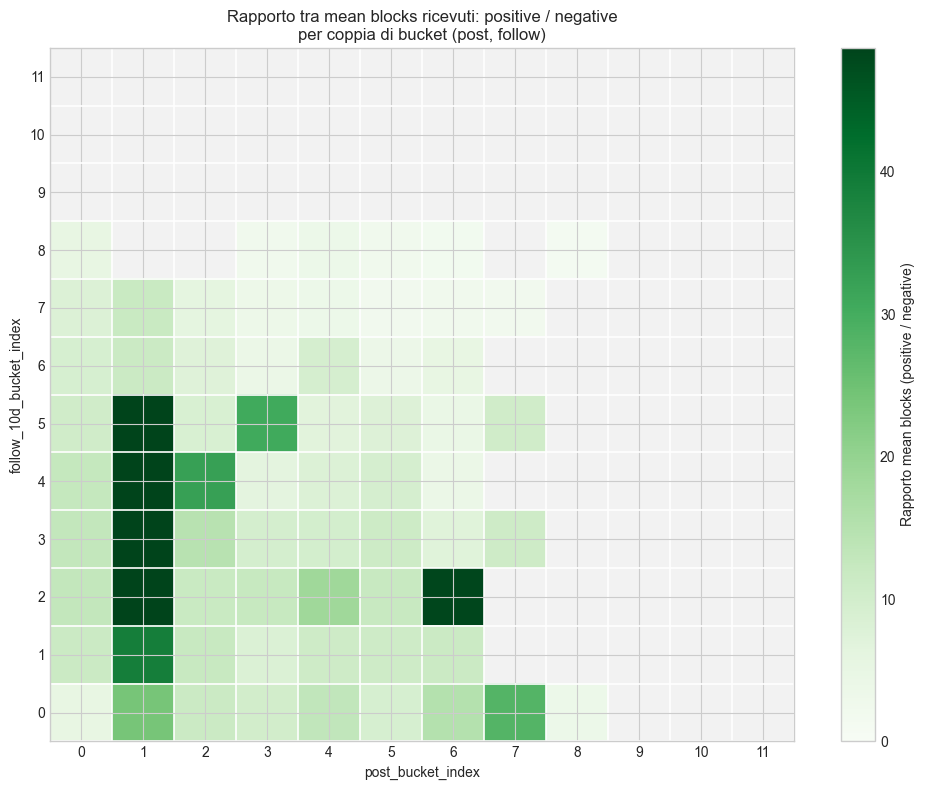

In [6]:
MIN_POS_BUCKET = 20
MIN_NEG_BUCKET = 200
ALL_BUCKETS = list(range(12))  # se i bucket sono 0..10

blocks_cols = set(q("DESCRIBE blocks")["column_name"])
if "follow_10d_bucket_index" in blocks_cols:
    follow_bucket_col = "follow_10d_bucket_index"
elif "follow_bucket_index" in blocks_cols:
    follow_bucket_col = "follow_bucket_index"
else:
    raise RuntimeError("Non trovo la colonna dei follow bucket nel dataset `blocks`.")

bucket_ratio = q(
    f"""
    WITH bucket_stats AS (
        SELECT
            sample,
            post_bucket_index,
            {follow_bucket_col} AS follow_bucket_index,
            COUNT(*) AS n_obs,
            AVG(n_blocks_received_10d) AS mean_blocks_10d
        FROM blocks
        GROUP BY sample, post_bucket_index, follow_bucket_index
    ),
    wide AS (
        SELECT
            post_bucket_index,
            follow_bucket_index,
            MAX(CASE WHEN sample = 'positive' THEN n_obs END) AS n_pos,
            MAX(CASE WHEN sample = 'negative' THEN n_obs END) AS n_neg,
            MAX(CASE WHEN sample = 'positive' THEN mean_blocks_10d END) AS pos_mean_blocks_10d,
            MAX(CASE WHEN sample = 'negative' THEN mean_blocks_10d END) AS neg_mean_blocks_10d
        FROM bucket_stats
        GROUP BY post_bucket_index, follow_bucket_index
    )
    SELECT
        post_bucket_index,
        follow_bucket_index,
        n_pos,
        n_neg,
        pos_mean_blocks_10d,
        neg_mean_blocks_10d,
        pos_mean_blocks_10d / NULLIF(neg_mean_blocks_10d, 0) AS ratio_pos_neg_mean_blocks
    FROM wide
    WHERE COALESCE(n_pos, 0) >= {MIN_POS_BUCKET}
      AND COALESCE(n_neg, 0) >= {MIN_NEG_BUCKET}
      AND pos_mean_blocks_10d IS NOT NULL
      AND neg_mean_blocks_10d IS NOT NULL
      AND neg_mean_blocks_10d > 0
    """
)

heatmap_df = (
    bucket_ratio
    .pivot(
        index="follow_bucket_index",
        columns="post_bucket_index",
        values="ratio_pos_neg_mean_blocks",
    )
    .reindex(index=ALL_BUCKETS, columns=ALL_BUCKETS)
)

values = heatmap_df.to_numpy(dtype=float)

cmap = plt.get_cmap("Greens").copy()
cmap.set_bad("#f2f2f2")  # celle senza dato / filtrate

vmax = np.nanpercentile(values, 95)
if not np.isfinite(vmax) or vmax <= 0:
    vmax = np.nanmax(values)

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    values,
    origin="lower",
    aspect="auto",
    cmap=cmap,
    vmin=0,
    vmax=vmax,
)

ax.set_xticks(np.arange(len(ALL_BUCKETS)))
ax.set_xticklabels(ALL_BUCKETS)
ax.set_yticks(np.arange(len(ALL_BUCKETS)))
ax.set_yticklabels(ALL_BUCKETS)

ax.set_xlabel("post_bucket_index")
ax.set_ylabel("follow_10d_bucket_index")
ax.set_title(
    "Rapporto tra mean blocks ricevuti: positive / negative\n"
    "per coppia di bucket (post, follow)"
)

ax.set_xticks(np.arange(-0.5, len(ALL_BUCKETS), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(ALL_BUCKETS), 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=1.2)
ax.tick_params(which="minor", bottom=False, left=False)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Rapporto mean blocks (positive / negative)")

plt.tight_layout()
plt.show()


## 4. Timing del segnale nei 10 giorni pre-evento

Questa sezione sintetizza la dinamica giornaliera dei blocchi.

Guardiamo tre cose diverse:
- a sinistra: probabilita' giornaliera media di osservare almeno un blocco;
- al centro: tra le osservazioni con almeno un blocco, quota media del volume totale che cade in ciascun giorno relativo;
- a destra: numero medio di blocchi osservati in ciascun giorno, in valore assoluto.

Il pannello centrale legge la **concentrazione temporale** del segnale, mentre il pannello di destra legge il **volume medio giornaliero**.


,sample,share_last_1d_cond_any,share_last_3d_cond_any,share_days_3_to_10_cond_any
0,negative,0.1075,0.3110,0.6890
1,positive,0.5563,0.7877,0.2123


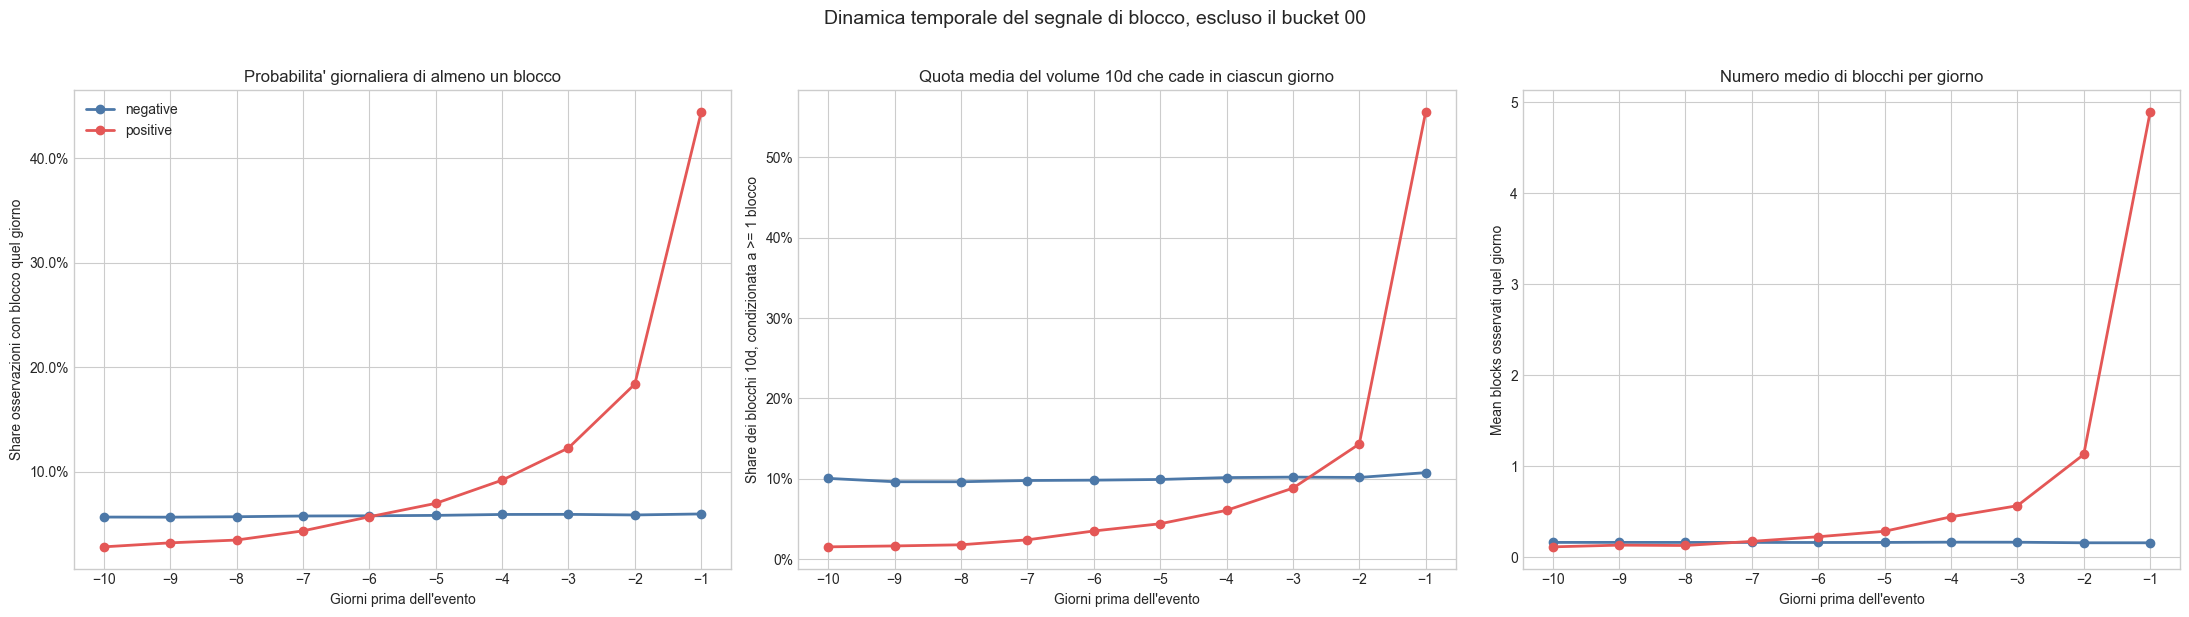

In [9]:
blocks_cols = set(q("DESCRIBE blocks")["column_name"])
if "follow_10d_bucket_index" in blocks_cols:
    follow_bucket_col = "follow_10d_bucket_index"
elif "follow_bucket_index" in blocks_cols:
    follow_bucket_col = "follow_bucket_index"
else:
    raise RuntimeError("Non trovo la colonna dei follow bucket nel dataset `blocks`.")

daily_profile = q(
    f"""
    WITH filtered_blocks AS (
        SELECT *
        FROM blocks
        WHERE NOT (
            post_bucket_index = 0
            AND {follow_bucket_col} = 0
        )
    ),
    stacked AS (
        SELECT sample, -1  AS relative_day, n_blocks_day_0 AS blocks_day, has_block_day_0 AS has_block_day,
               CASE WHEN n_blocks_received_10d > 0 THEN CAST(n_blocks_day_0 AS DOUBLE) / n_blocks_received_10d END AS share_of_window
        FROM filtered_blocks
        UNION ALL
        SELECT sample, -2, n_blocks_day_1, has_block_day_1,
               CASE WHEN n_blocks_received_10d > 0 THEN CAST(n_blocks_day_1 AS DOUBLE) / n_blocks_received_10d END
        FROM filtered_blocks
        UNION ALL
        SELECT sample, -3, n_blocks_day_2, has_block_day_2,
               CASE WHEN n_blocks_received_10d > 0 THEN CAST(n_blocks_day_2 AS DOUBLE) / n_blocks_received_10d END
        FROM filtered_blocks
        UNION ALL
        SELECT sample, -4, n_blocks_day_3, has_block_day_3,
               CASE WHEN n_blocks_received_10d > 0 THEN CAST(n_blocks_day_3 AS DOUBLE) / n_blocks_received_10d END
        FROM filtered_blocks
        UNION ALL
        SELECT sample, -5, n_blocks_day_4, has_block_day_4,
               CASE WHEN n_blocks_received_10d > 0 THEN CAST(n_blocks_day_4 AS DOUBLE) / n_blocks_received_10d END
        FROM filtered_blocks
        UNION ALL
        SELECT sample, -6, n_blocks_day_5, has_block_day_5,
               CASE WHEN n_blocks_received_10d > 0 THEN CAST(n_blocks_day_5 AS DOUBLE) / n_blocks_received_10d END
        FROM filtered_blocks
        UNION ALL
        SELECT sample, -7, n_blocks_day_6, has_block_day_6,
               CASE WHEN n_blocks_received_10d > 0 THEN CAST(n_blocks_day_6 AS DOUBLE) / n_blocks_received_10d END
        FROM filtered_blocks
        UNION ALL
        SELECT sample, -8, n_blocks_day_7, has_block_day_7,
               CASE WHEN n_blocks_received_10d > 0 THEN CAST(n_blocks_day_7 AS DOUBLE) / n_blocks_received_10d END
        FROM filtered_blocks
        UNION ALL
        SELECT sample, -9, n_blocks_day_8, has_block_day_8,
               CASE WHEN n_blocks_received_10d > 0 THEN CAST(n_blocks_day_8 AS DOUBLE) / n_blocks_received_10d END
        FROM filtered_blocks
        UNION ALL
        SELECT sample, -10, n_blocks_day_9, has_block_day_9,
               CASE WHEN n_blocks_received_10d > 0 THEN CAST(n_blocks_day_9 AS DOUBLE) / n_blocks_received_10d END
        FROM filtered_blocks
    )
    SELECT
        sample,
        relative_day,
        AVG(has_block_day) AS share_has_block_day,
        AVG(blocks_day) AS mean_blocks_day,
        AVG(share_of_window) AS mean_share_of_window_cond_any
    FROM stacked
    GROUP BY sample, relative_day
    ORDER BY relative_day
    """
)

timing_windows = q(
    f"""
    WITH filtered_blocks AS (
        SELECT *
        FROM blocks
        WHERE NOT (
            post_bucket_index = 0
            AND {follow_bucket_col} = 0
        )
    )
    SELECT
        sample,
        AVG(CASE WHEN n_blocks_received_10d > 0 THEN CAST(n_blocks_0_1d AS DOUBLE) / n_blocks_received_10d END) AS share_last_1d_cond_any,
        AVG(CASE WHEN n_blocks_received_10d > 0 THEN CAST(n_blocks_0_1d + n_blocks_1_3d AS DOUBLE) / n_blocks_received_10d END) AS share_last_3d_cond_any,
        AVG(CASE WHEN n_blocks_received_10d > 0 THEN CAST(n_blocks_3_7d + n_blocks_7_10d AS DOUBLE) / n_blocks_received_10d END) AS share_days_3_to_10_cond_any
    FROM filtered_blocks
    GROUP BY sample
    ORDER BY sample
    """
)
display(timing_windows)

fig, axes = plt.subplots(1, 3, figsize=(22, 6), sharex=True)

for sample in ["negative", "positive"]:
    tmp = daily_profile[daily_profile["sample"] == sample]
    axes[0].plot(tmp["relative_day"], tmp["share_has_block_day"], marker="o", linewidth=2, color=COLORS[sample], label=sample)
    axes[1].plot(tmp["relative_day"], tmp["mean_share_of_window_cond_any"], marker="o", linewidth=2, color=COLORS[sample], label=sample)
    axes[2].plot(tmp["relative_day"], tmp["mean_blocks_day"], marker="o", linewidth=2, color=COLORS[sample], label=sample)

axes[0].set_title("Probabilita' giornaliera di almeno un blocco")
axes[0].set_ylabel("Share osservazioni con blocco quel giorno")
axes[0].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[0].legend()

axes[1].set_title("Quota media del volume 10d che cade in ciascun giorno")
axes[1].set_ylabel("Share dei blocchi 10d, condizionata a >= 1 blocco")
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))

axes[2].set_title("Numero medio di blocchi per giorno")
axes[2].set_ylabel("Mean blocks osservati quel giorno")

for ax in axes:
    ax.set_xlabel("Giorni prima dell'evento")
    ax.set_xticks(list(range(-10, 0)))

fig.suptitle("Dinamica temporale del segnale di blocco, escluso il bucket 00", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()


## 5. Perche' nei giorni lontani i positivi possono stare sotto ai negativi?

Il pattern aggregato dei box plot giornalieri suggerisce che, lontano dall'evento, i positivi possano avere una quota di blocco giornaliera anche piu' bassa dei negativi. Qui proviamo a capire **perche'**.

La lettura che ci interessa e' doppia:
- `composizione`: i positivi sono molto piu' concentrati nei gruppi a bassissima esposizione, soprattutto `0 post / 0 follows`;
- `timing condizionato`: entro ciascun macro-gruppo di esposizione il segnale dei positivi tende ad addensarsi piu' vicino al takedown.


,sample,exposure_corner,n_obs,share_of_sample
0,negative,00,123906,0.3381
1,positive,00,28802,0.6023
2,negative,0p,38214,0.1043
3,positive,0p,5914,0.1237
4,negative,p0,63086,0.1721
5,positive,p0,4775,0.0999
6,negative,pp,141309,0.3855
7,positive,pp,8330,0.1742


exposure_corner,00,0p,p0,pp
sample,,,,
negative,0.3381,0.1043,0.1721,0.3855
positive,0.6023,0.1237,0.0999,0.1742


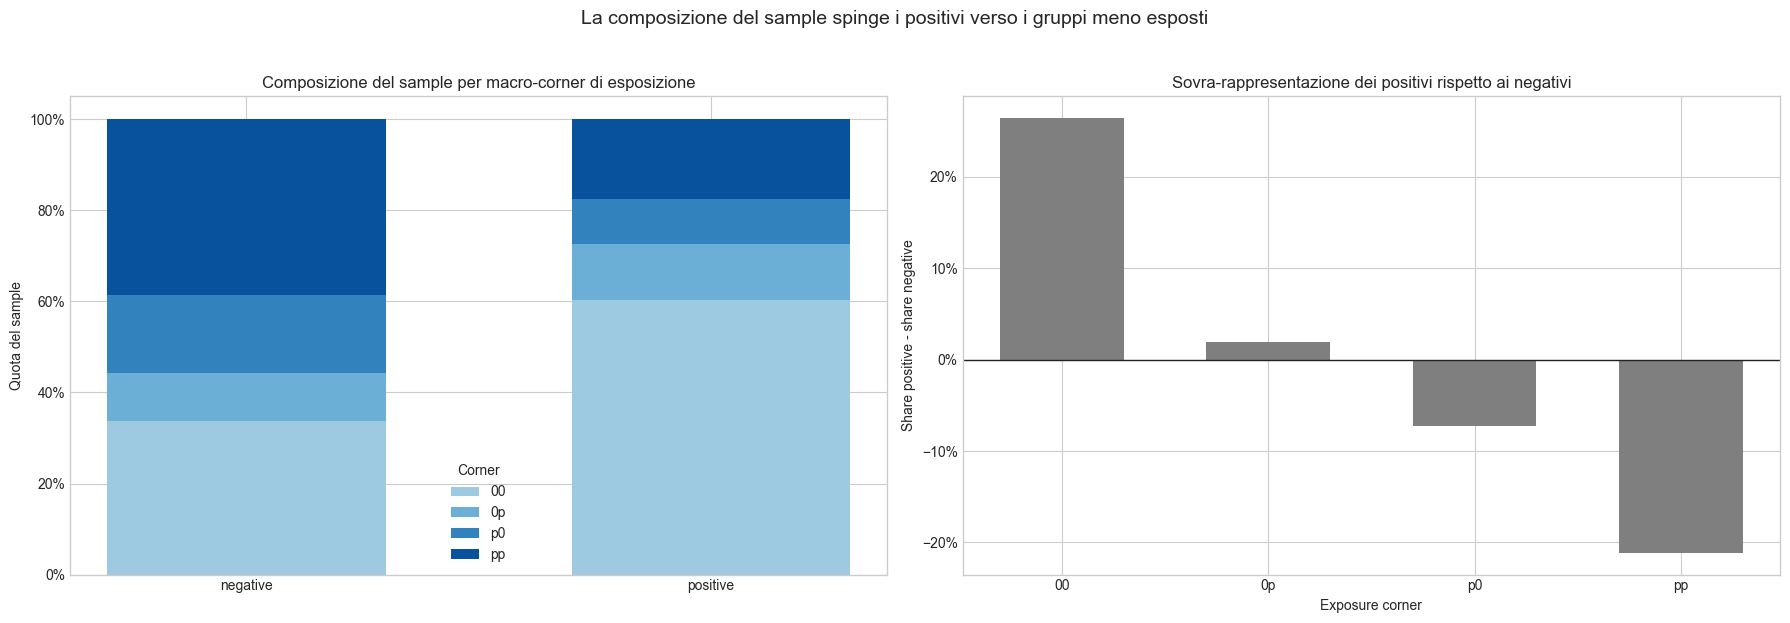

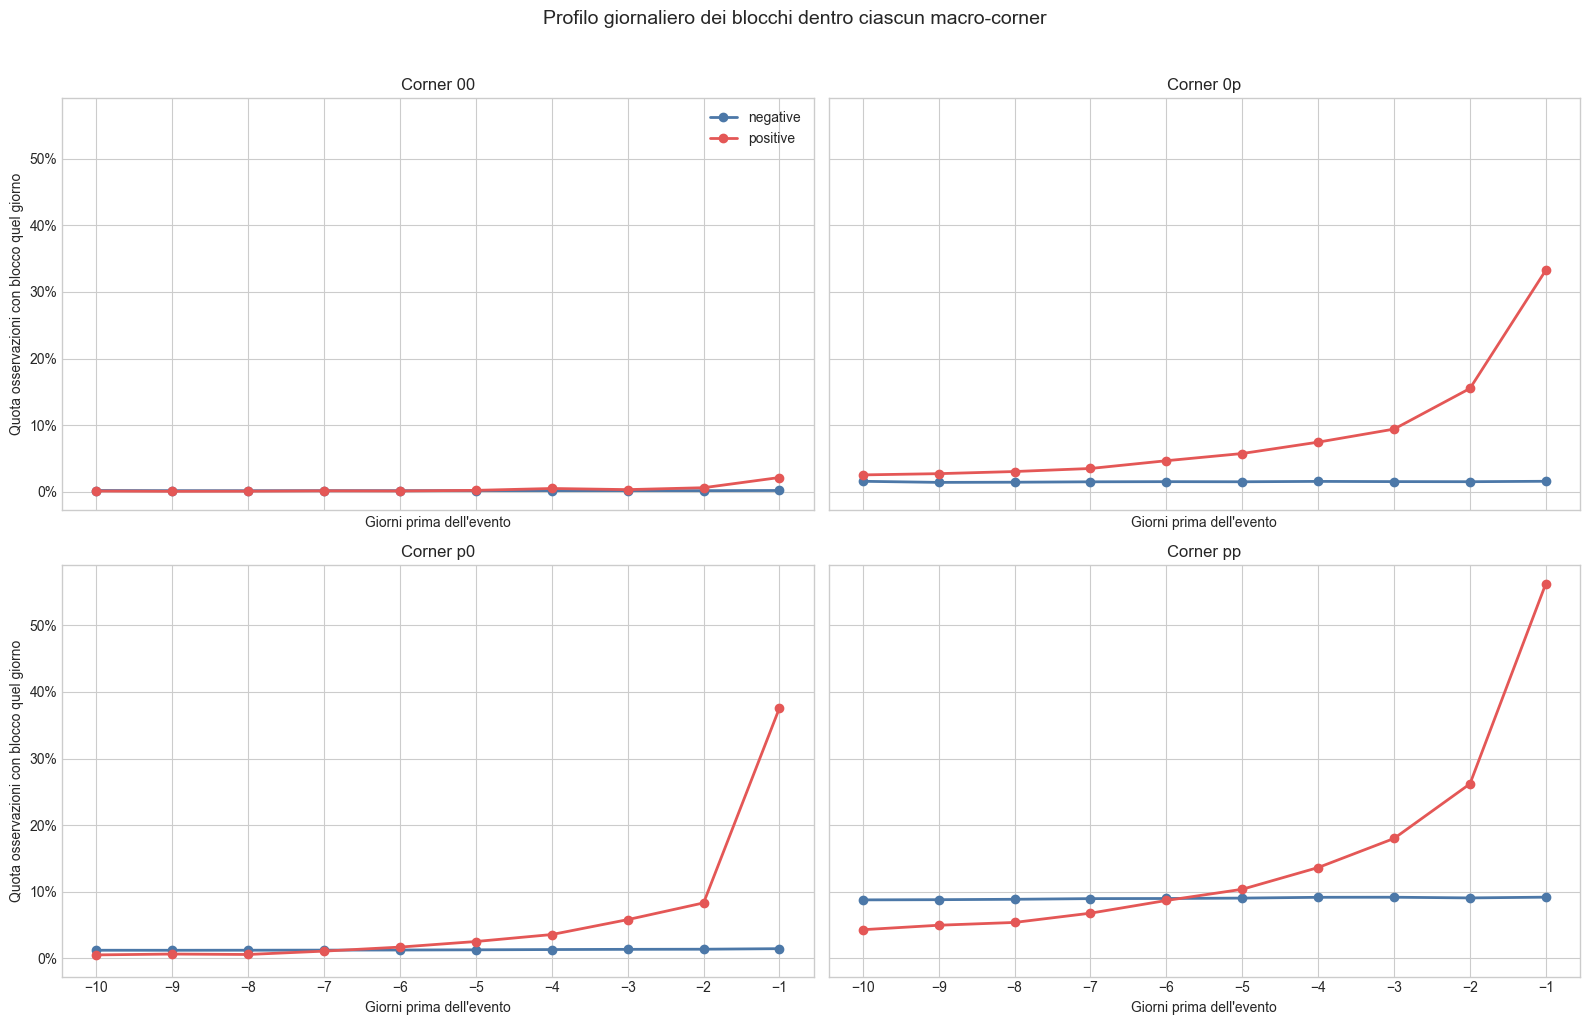

In [10]:
corner_summary = q(
    """
    WITH cornered AS (
        SELECT
            sample,
            did_anon,
            event_time,
            CASE
                WHEN n_posts_10d = 0 AND incoming_follows_10d = 0 THEN '00'
                WHEN n_posts_10d = 0 AND incoming_follows_10d > 0 THEN '0p'
                WHEN n_posts_10d > 0 AND incoming_follows_10d = 0 THEN 'p0'
                ELSE 'pp'
            END AS exposure_corner
        FROM blocks
    ),
    first_obs AS (
        SELECT
            sample,
            did_anon,
            exposure_corner,
            ROW_NUMBER() OVER (PARTITION BY sample, did_anon ORDER BY event_time) AS rn
        FROM cornered
    ),
    account_corner AS (
        SELECT sample, did_anon, exposure_corner
        FROM first_obs
        WHERE rn = 1
    ),
    corner_accounts AS (
        SELECT sample, exposure_corner, COUNT(*) AS n_obs
        FROM account_corner
        GROUP BY sample, exposure_corner
    ),
    sample_accounts AS (
        SELECT sample, COUNT(*) AS n_accounts_total
        FROM account_corner
        GROUP BY sample
    )
    SELECT
        c.sample,
        c.exposure_corner,
        c.n_obs,
        c.n_obs * 1.0 / s.n_accounts_total AS share_of_sample
    FROM corner_accounts c
    JOIN sample_accounts s USING (sample)
    ORDER BY c.exposure_corner, c.sample
    """
)
display(corner_summary)

corner_daily_profile = q(
    """
    WITH cornered AS (
        SELECT
            sample,
            CASE
                WHEN n_posts_10d = 0 AND incoming_follows_10d = 0 THEN '00'
                WHEN n_posts_10d = 0 AND incoming_follows_10d > 0 THEN '0p'
                WHEN n_posts_10d > 0 AND incoming_follows_10d = 0 THEN 'p0'
                ELSE 'pp'
            END AS exposure_corner,
            *
        FROM blocks
    ),
    stacked AS (
        SELECT sample, exposure_corner, -10 AS relative_day, AVG(has_block_day_9) AS share_has_block_day FROM cornered GROUP BY sample, exposure_corner
        UNION ALL SELECT sample, exposure_corner, -9, AVG(has_block_day_8) FROM cornered GROUP BY sample, exposure_corner
        UNION ALL SELECT sample, exposure_corner, -8, AVG(has_block_day_7) FROM cornered GROUP BY sample, exposure_corner
        UNION ALL SELECT sample, exposure_corner, -7, AVG(has_block_day_6) FROM cornered GROUP BY sample, exposure_corner
        UNION ALL SELECT sample, exposure_corner, -6, AVG(has_block_day_5) FROM cornered GROUP BY sample, exposure_corner
        UNION ALL SELECT sample, exposure_corner, -5, AVG(has_block_day_4) FROM cornered GROUP BY sample, exposure_corner
        UNION ALL SELECT sample, exposure_corner, -4, AVG(has_block_day_3) FROM cornered GROUP BY sample, exposure_corner
        UNION ALL SELECT sample, exposure_corner, -3, AVG(has_block_day_2) FROM cornered GROUP BY sample, exposure_corner
        UNION ALL SELECT sample, exposure_corner, -2, AVG(has_block_day_1) FROM cornered GROUP BY sample, exposure_corner
        UNION ALL SELECT sample, exposure_corner, -1, AVG(has_block_day_0) FROM cornered GROUP BY sample, exposure_corner
    )
    SELECT *
    FROM stacked
    ORDER BY exposure_corner, relative_day, sample
    """
)

corner_order = ["00", "0p", "p0", "pp"]
samples = ["negative", "positive"]

composition = (
    corner_summary
    .pivot(index="sample", columns="exposure_corner", values="share_of_sample")
    .reindex(["negative", "positive"])
    [corner_order]
)
display(composition)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

left = np.zeros(len(composition.index))
color_map = {
    "00": "#9ecae1",
    "0p": "#6baed6",
    "p0": "#3182bd",
    "pp": "#08519c",
}
for corner in corner_order:
    values = composition[corner].to_numpy()
    axes[0].bar(
        composition.index,
        values,
        bottom=left,
        color=color_map[corner],
        width=0.6,
        label=corner,
    )
    left = left + values
axes[0].set_title("Composizione del sample per macro-corner di esposizione")
axes[0].set_ylabel("Quota del sample")
axes[0].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[0].legend(title="Corner")

axes[1].bar(
    composition.columns,
    composition.loc["positive"].to_numpy() - composition.loc["negative"].to_numpy(),
    color="#7f7f7f",
    width=0.6,
)
axes[1].axhline(0, color="#222222", linewidth=1)
axes[1].set_title("Sovra-rappresentazione dei positivi rispetto ai negativi")
axes[1].set_ylabel("Share positive - share negative")
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].set_xlabel("Exposure corner")

fig.suptitle("La composizione del sample spinge i positivi verso i gruppi meno esposti", fontsize=14, y=1.03)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, corner in zip(axes, corner_order):
    tmp = corner_daily_profile[corner_daily_profile["exposure_corner"] == corner]
    for sample in samples:
        sample_tmp = tmp[tmp["sample"] == sample]
        ax.plot(
            sample_tmp["relative_day"],
            sample_tmp["share_has_block_day"],
            marker="o",
            linewidth=2,
            color=COLORS[sample],
            label=sample,
        )
    ax.set_title(f"Corner {corner}")
    ax.set_xlabel("Giorni prima dell'evento")
    ax.set_xticks(list(range(-10, 0)))
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))

axes[0].set_ylabel("Quota osservazioni con blocco quel giorno")
axes[2].set_ylabel("Quota osservazioni con blocco quel giorno")
axes[0].legend()

fig.suptitle("Profilo giornaliero dei blocchi dentro ciascun macro-corner", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()



## 6. Focus dedicato: account con `0 post` e `0 incoming follows`

Questa non e' una semplice appendice. Ci interessa capire se, proprio dove il volume e' basso, il segnale dei blocchi riesce comunque a separare i positivi dai negativi.


,sample,n_obs_zero_zero,block_rate_10d,mean_blocks_10d,median_blocks_10d,p90_blocks_10d,mean_unique_blockers_10d
0,negative,1341731,0.0140,0.0175,0.0000,0.0000,0.0168
1,positive,28802,0.0371,0.0867,0.0000,0.0000,0.0861


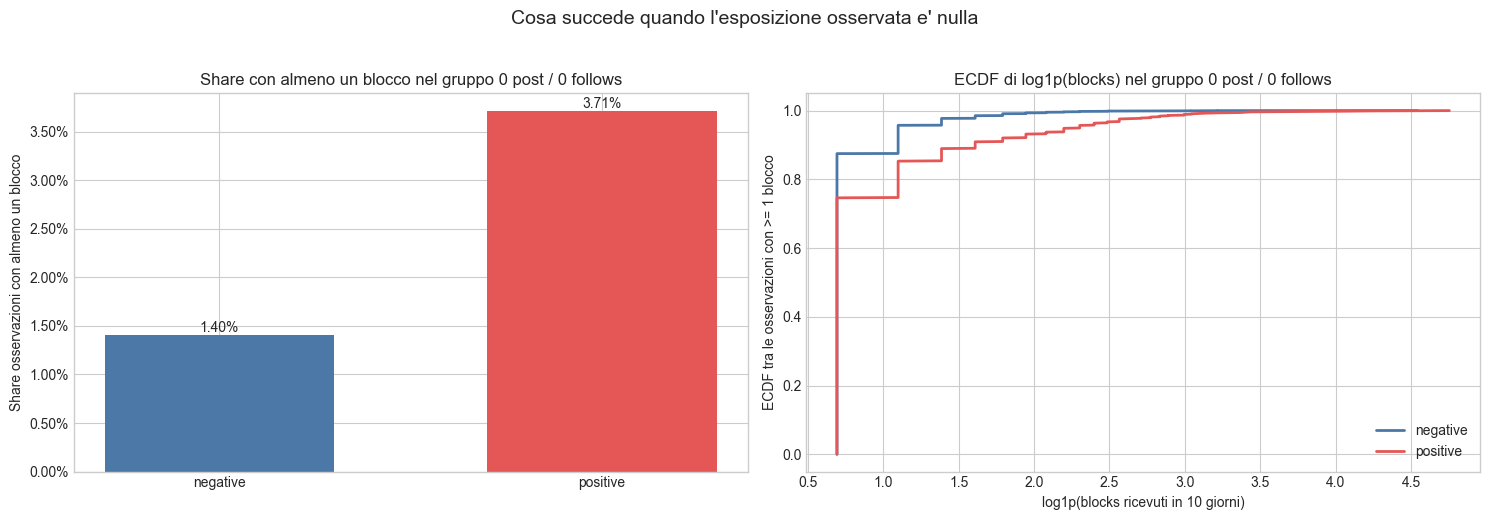

In [8]:
zero_zero_summary = q(
    """
    SELECT
        sample,
        COUNT(*) AS n_obs_zero_zero,
        AVG(has_block_10d) AS block_rate_10d,
        AVG(n_blocks_received_10d) AS mean_blocks_10d,
        MEDIAN(n_blocks_received_10d) AS median_blocks_10d,
        QUANTILE_CONT(n_blocks_received_10d, 0.90) AS p90_blocks_10d,
        AVG(n_unique_blockers_10d) AS mean_unique_blockers_10d
    FROM blocks
    WHERE n_posts_10d = 0
      AND incoming_follows_10d = 0
    GROUP BY sample
    ORDER BY sample
    """
)
display(zero_zero_summary)

zero_zero_blocked = q(
    """
    SELECT
        sample,
        LN(1 + n_blocks_received_10d) AS log_blocks_10d
    FROM blocks
    WHERE n_posts_10d = 0
      AND incoming_follows_10d = 0
      AND n_blocks_received_10d > 0
    ORDER BY sample
    """
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

bars = zero_zero_summary.set_index("sample")["block_rate_10d"].reindex(["negative", "positive"])
axes[0].bar(bars.index, bars.values, color=[COLORS["negative"], COLORS["positive"]], width=0.6)
axes[0].set_title("Share con almeno un blocco nel gruppo 0 post / 0 follows")
axes[0].set_ylabel("Share osservazioni con almeno un blocco")
axes[0].yaxis.set_major_formatter(PercentFormatter(1.0))
for idx, value in enumerate(bars.values):
    axes[0].text(idx, value, f"{value:.2%}", ha="center", va="bottom")

for sample in ["negative", "positive"]:
    values = np.sort(zero_zero_blocked.loc[zero_zero_blocked["sample"] == sample, "log_blocks_10d"].to_numpy())
    if len(values) == 0:
        continue
    y = np.arange(1, len(values) + 1) / len(values)
    axes[1].plot(values, y, linewidth=2, color=COLORS[sample], label=sample)

axes[1].set_title("ECDF di log1p(blocks) nel gruppo 0 post / 0 follows")
axes[1].set_xlabel("log1p(blocks ricevuti in 10 giorni)")
axes[1].set_ylabel("ECDF tra le osservazioni con >= 1 blocco")
axes[1].legend()

fig.suptitle("Cosa succede quando l'esposizione osservata e' nulla", fontsize=14, y=1.03)
fig.tight_layout()
plt.show()


In [ ]:
python <<'PY'
import duckdb

POSITIVE = "positive_blocks_analysis_10d_mar2026_v3.parquet"
PROFILES = "03-profiles.parquet"

con = duckdb.connect()

positive_cols = {
    row[0] for row in con.execute(
        f"DESCRIBE SELECT * FROM read_parquet('{POSITIVE}')"
    ).fetchall()
}

if "follow_10d_bucket_index" in positive_cols:
    follow_bucket_col = "follow_10d_bucket_index"
elif "follow_bucket_index" in positive_cols:
    follow_bucket_col = "follow_bucket_index"
else:
    raise RuntimeError(
        "Non trovo né 'follow_10d_bucket_index' né 'follow_bucket_index' "
        "nel dataset positivo."
    )

# 1. Controllo: il dataset positivo dovrebbe avere una riga per DID

positive_check = con.execute(f"""
    SELECT
        COUNT(*) AS n_rows,
        COUNT(DISTINCT did) AS n_distinct_dids,
        COUNT(*) - COUNT(DISTINCT did) AS n_duplicate_rows
    FROM read_parquet('{POSITIVE}');
""").fetchdf()

print("\n=== CONTROLLO DATASET POSITIVO ===")
print(positive_check.to_string(index=False))

# 2. Controllo: quante righe profiles corrispondono ai DID positivi

profiles_check = con.execute(f"""
    WITH positive_dids AS (
        SELECT DISTINCT did
        FROM read_parquet('{POSITIVE}')
    ),
    profile_rows_per_positive_did AS (
        SELECT
            pr.did_id,
            COUNT(*) AS n_profile_rows,
            COUNT(DISTINCT CAST(pr.created_at AS TIMESTAMPTZ)) AS n_distinct_created_at
        FROM read_parquet('{PROFILES}') pr
        INNER JOIN positive_dids p
            ON pr.did_id = p.did
        GROUP BY pr.did_id
    )
    SELECT
        COUNT(*) AS n_positive_dids_matched_in_profiles,
        COUNT(*) FILTER (WHERE n_profile_rows > 1) AS n_dids_with_multiple_profile_rows,
        SUM(n_profile_rows) AS n_profile_rows_after_match,
        COUNT(*) FILTER (WHERE n_distinct_created_at > 1) AS n_dids_with_different_created_at
    FROM profile_rows_per_positive_did;
""").fetchdf()

print("\n=== CONTROLLO DUPLICATI IN PROFILES PER I DID POSITIVI ===")
print(profiles_check.to_string(index=False))

# 3. Risultati corretti: una sola created_at per account
#    MIN(created_at) = data di creazione più antica osservata

result = con.execute(f"""
    WITH profiles_one_row_per_did AS (
        SELECT
            did_id,
            MIN(CAST(created_at AS TIMESTAMPTZ)) AS created_at
        FROM read_parquet('{PROFILES}')
        GROUP BY did_id
    ),
    positive_with_created_at AS (
        SELECT
            p.did,
            CAST(p.event_time AS TIMESTAMPTZ) AS event_time,
            pr.created_at,
            p.post_bucket_index,
            p.{follow_bucket_col} AS follow_bucket_index,
            CAST(p.event_time AS TIMESTAMPTZ) - pr.created_at AS account_lifetime
        FROM read_parquet('{POSITIVE}') p
        INNER JOIN profiles_one_row_per_did pr
            ON p.did = pr.did_id
    ),
    younger_than_10d AS (
        SELECT *
        FROM positive_with_created_at
        WHERE account_lifetime < INTERVAL '10 days'
    ),
    bucket_00 AS (
        SELECT *
        FROM positive_with_created_at
        WHERE post_bucket_index = 0
          AND follow_bucket_index = 0
    ),
    younger_than_10d_bucket_00 AS (
        SELECT *
        FROM younger_than_10d
        WHERE post_bucket_index = 0
          AND follow_bucket_index = 0
    )
    SELECT
        (SELECT COUNT(DISTINCT did) FROM younger_than_10d)
            AS n_accounts_event_time_minus_created_at_lt_10d,

        (SELECT COUNT(DISTINCT did) FROM bucket_00)
            AS n_total_accounts_in_bucket_00,

        (SELECT COUNT(DISTINCT did) FROM younger_than_10d_bucket_00)
            AS n_lt_10d_in_bucket_00,

        (
            SELECT AVG(lifetime_days)
            FROM (
                SELECT
                    did,
                    MAX(EXTRACT(EPOCH FROM account_lifetime) / 86400.0) AS lifetime_days
                FROM younger_than_10d_bucket_00
                GROUP BY did
            )
        ) AS avg_account_lifetime_days_lt_10d_bucket_00;
""").fetchdf()

print("\n=== RISULTATI CORRETTI SU ACCOUNT UNICI ===")
print(result.to_string(index=False))

con.close()
PY



## RISULTATO OTTENUTO
#=== RISULTATI CORRETTI SU ACCOUNT UNICI ===
# n_accounts_event_time_minus_created_at_lt_10d  n_total_accounts_in_bucket_00  n_lt_10d_in_bucket_00  avg_account_lifetime_days_lt_10d_bucket_00
#                                         34334                          20574                  19530                                    0.378466

# quindi: quasi la totalità degli account nel corner 00 ha un event_time - created_at < 10 giorni,
# e la durata media di questi account è di circa 0.38 giorni (circa 9 ore).

## 7. Dettaglio descrittivo e box plot giornalieri

Qui riportiamo il dettaglio descrittivo piu' ricco che prima era all'inizio del notebook:
- confronto esteso tra positivi e negativi;
- riepilogo specifico del gruppo `0 post / 0 follows`;
- box plot giornalieri del segnale, sia in forma **indipendente** sia in forma **cumulata** lungo la finestra di 10 giorni.

Nei box plot, per ogni giorno relativo mostriamo la distribuzione della **quota di osservazioni con almeno un blocco** attraverso i diversi `event_day` di calendario, separando positivi e negativi.


,sample,n_obs,n_accounts,share_any_block_10d,mean_blocks_received_10d,median_blocks_received_10d,p95_blocks_received_10d,mean_unique_blockers_10d,mean_posts_10d,median_posts_10d,mean_incoming_follows_10d,median_incoming_follows_10d
0,negative,4031665,366515,0.1809,1.1073,0.0000,3.0000,1.0873,20.0393,1.0000,8.2894,0.0000
1,positive,47821,47821,0.2782,3.2787,0.0000,9.0000,3.2485,7.2021,0.0000,4.8918,0.0000


,sample,n_obs_zero_zero,share_zero_zero,block_rate_zero_zero,mean_blocks_zero_zero
0,negative,1341731,0.3328,0.0140,0.0175
1,positive,28802,0.6023,0.0371,0.0867


,sample,event_day,relative_day,daily_share,cumulative_share
0,negative,2026-03-11,-10,0.0404,0.0404
1,negative,2026-03-12,-10,0.0382,0.0382
2,negative,2026-03-13,-10,0.0370,0.0370
3,negative,2026-03-14,-10,0.0396,0.0396
4,negative,2026-03-15,-10,0.0371,0.0371
5,negative,2026-03-16,-10,0.0353,0.0353
6,negative,2026-03-17,-10,0.0381,0.0381
7,negative,2026-03-18,-10,0.0406,0.0406
8,negative,2026-03-19,-10,0.0385,0.0385
9,negative,2026-03-20,-10,0.0369,0.0369


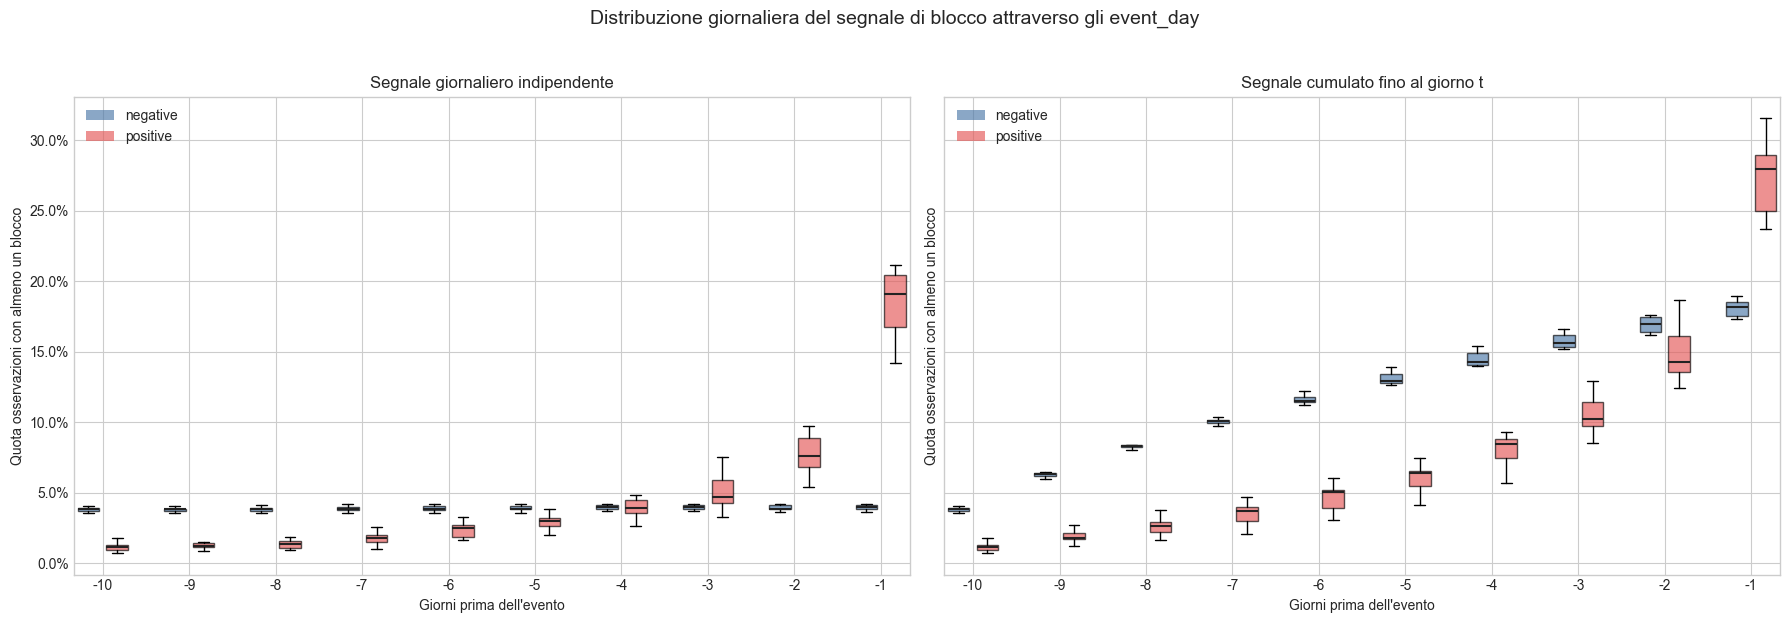

In [10]:
summary = q(
    """
    SELECT
        sample,
        COUNT(*) AS n_obs,
        COUNT(DISTINCT did_anon) AS n_accounts,
        AVG(has_block_10d) AS share_any_block_10d,
        AVG(n_blocks_received_10d) AS mean_blocks_received_10d,
        MEDIAN(n_blocks_received_10d) AS median_blocks_received_10d,
        QUANTILE_CONT(n_blocks_received_10d, 0.95) AS p95_blocks_received_10d,
        AVG(n_unique_blockers_10d) AS mean_unique_blockers_10d,
        AVG(n_posts_10d) AS mean_posts_10d,
        MEDIAN(n_posts_10d) AS median_posts_10d,
        AVG(incoming_follows_10d) AS mean_incoming_follows_10d,
        MEDIAN(incoming_follows_10d) AS median_incoming_follows_10d
    FROM blocks
    GROUP BY sample
    ORDER BY sample
    """
)
display(summary)

zero_zero_headline = q(
    """
    SELECT
        sample,
        COUNT(*) FILTER (WHERE n_posts_10d = 0 AND incoming_follows_10d = 0) AS n_obs_zero_zero,
        AVG((n_posts_10d = 0 AND incoming_follows_10d = 0)::INT) AS share_zero_zero,
        AVG(has_block_10d) FILTER (WHERE n_posts_10d = 0 AND incoming_follows_10d = 0) AS block_rate_zero_zero,
        AVG(n_blocks_received_10d) FILTER (WHERE n_posts_10d = 0 AND incoming_follows_10d = 0) AS mean_blocks_zero_zero
    FROM blocks
    GROUP BY sample
    ORDER BY sample
    """
)
display(zero_zero_headline)

daily_boxplot_df = q(
    """
    WITH per_event_day AS (
        SELECT
            sample,
            event_day,
            AVG(has_block_day_9) AS share_has_block_day_m10,
            AVG(has_block_day_8) AS share_has_block_day_m9,
            AVG(has_block_day_7) AS share_has_block_day_m8,
            AVG(has_block_day_6) AS share_has_block_day_m7,
            AVG(has_block_day_5) AS share_has_block_day_m6,
            AVG(has_block_day_4) AS share_has_block_day_m5,
            AVG(has_block_day_3) AS share_has_block_day_m4,
            AVG(has_block_day_2) AS share_has_block_day_m3,
            AVG(has_block_day_1) AS share_has_block_day_m2,
            AVG(has_block_day_0) AS share_has_block_day_m1,

            AVG((n_blocks_day_9 > 0)::INT) AS share_cum_has_block_day_m10,
            AVG((n_blocks_day_9 + n_blocks_day_8 > 0)::INT) AS share_cum_has_block_day_m9,
            AVG((n_blocks_day_9 + n_blocks_day_8 + n_blocks_day_7 > 0)::INT) AS share_cum_has_block_day_m8,
            AVG((n_blocks_day_9 + n_blocks_day_8 + n_blocks_day_7 + n_blocks_day_6 > 0)::INT) AS share_cum_has_block_day_m7,
            AVG((n_blocks_day_9 + n_blocks_day_8 + n_blocks_day_7 + n_blocks_day_6 + n_blocks_day_5 > 0)::INT) AS share_cum_has_block_day_m6,
            AVG((n_blocks_day_9 + n_blocks_day_8 + n_blocks_day_7 + n_blocks_day_6 + n_blocks_day_5 + n_blocks_day_4 > 0)::INT) AS share_cum_has_block_day_m5,
            AVG((n_blocks_day_9 + n_blocks_day_8 + n_blocks_day_7 + n_blocks_day_6 + n_blocks_day_5 + n_blocks_day_4 + n_blocks_day_3 > 0)::INT) AS share_cum_has_block_day_m4,
            AVG((n_blocks_day_9 + n_blocks_day_8 + n_blocks_day_7 + n_blocks_day_6 + n_blocks_day_5 + n_blocks_day_4 + n_blocks_day_3 + n_blocks_day_2 > 0)::INT) AS share_cum_has_block_day_m3,
            AVG((n_blocks_day_9 + n_blocks_day_8 + n_blocks_day_7 + n_blocks_day_6 + n_blocks_day_5 + n_blocks_day_4 + n_blocks_day_3 + n_blocks_day_2 + n_blocks_day_1 > 0)::INT) AS share_cum_has_block_day_m2,
            AVG((n_blocks_received_10d > 0)::INT) AS share_cum_has_block_day_m1
        FROM blocks
        GROUP BY sample, event_day
    ),
    stacked AS (
        SELECT sample, event_day, -10 AS relative_day, share_has_block_day_m10 AS daily_share, share_cum_has_block_day_m10 AS cumulative_share FROM per_event_day
        UNION ALL SELECT sample, event_day, -9, share_has_block_day_m9, share_cum_has_block_day_m9 FROM per_event_day
        UNION ALL SELECT sample, event_day, -8, share_has_block_day_m8, share_cum_has_block_day_m8 FROM per_event_day
        UNION ALL SELECT sample, event_day, -7, share_has_block_day_m7, share_cum_has_block_day_m7 FROM per_event_day
        UNION ALL SELECT sample, event_day, -6, share_has_block_day_m6, share_cum_has_block_day_m6 FROM per_event_day
        UNION ALL SELECT sample, event_day, -5, share_has_block_day_m5, share_cum_has_block_day_m5 FROM per_event_day
        UNION ALL SELECT sample, event_day, -4, share_has_block_day_m4, share_cum_has_block_day_m4 FROM per_event_day
        UNION ALL SELECT sample, event_day, -3, share_has_block_day_m3, share_cum_has_block_day_m3 FROM per_event_day
        UNION ALL SELECT sample, event_day, -2, share_has_block_day_m2, share_cum_has_block_day_m2 FROM per_event_day
        UNION ALL SELECT sample, event_day, -1, share_has_block_day_m1, share_cum_has_block_day_m1 FROM per_event_day
    )
    SELECT *
    FROM stacked
    ORDER BY relative_day, sample, event_day
    """
)

display(daily_boxplot_df.head(12))

relative_days = list(range(-10, 0))
samples = ["negative", "positive"]
legend_handles = [Patch(facecolor=COLORS[sample], alpha=0.65, label=sample) for sample in samples]

def grouped_boxplot(ax, metric, title):
    data = []
    positions = []
    colors = []
    xticks = []
    base_positions = np.arange(len(relative_days)) * 3.0

    for idx, relative_day in enumerate(relative_days):
        for sample_offset, sample in enumerate(samples):
            values = daily_boxplot_df.loc[
                (daily_boxplot_df["relative_day"] == relative_day)
                & (daily_boxplot_df["sample"] == sample),
                metric,
            ].to_numpy()
            data.append(values)
            positions.append(base_positions[idx] + sample_offset)
            colors.append(COLORS[sample])
        xticks.append(base_positions[idx] + 0.5)

    bp = ax.boxplot(
        data,
        positions=positions,
        widths=0.75,
        showfliers=False,
        patch_artist=True,
        medianprops={"color": "#222222", "linewidth": 1.5},
    )
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.65)

    ax.set_xticks(xticks)
    ax.set_xticklabels(relative_days)
    ax.set_xlabel("Giorni prima dell'evento")
    ax.set_ylabel("Quota osservazioni con almeno un blocco")
    ax.set_title(title)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.legend(handles=legend_handles, loc="upper left")

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
grouped_boxplot(axes[0], "daily_share", "Segnale giornaliero indipendente")
grouped_boxplot(axes[1], "cumulative_share", "Segnale cumulato fino al giorno t")
fig.suptitle("Distribuzione giornaliera del segnale di blocco attraverso gli event_day", fontsize=14, y=1.03)
fig.tight_layout()
plt.show()
